# 20260908 — Petrovich HCF2 손실 무보정 검증

이 노트북은 **논문 손실값으로 fitting하지 않은 코드 계산값**과 Petrovich HCF2 실측 총손실을 비교합니다.

- 기준 논문: M. Petrovich et al., *First broadband optical fibre with an attenuation lower than 0.1 decibel per kilometre*, Nature Photonics 19, 1203–1208 (2025), DOI: 10.1038/s41566-025-01747-5.
- 해석식 검산: M. Bache et al., *Poor-man's model of hollow-core anti-resonant fibers*, JOSA B 36, 69–80 (2019), DOI: 10.1364/JOSAB.36.000069.
- 다층 동심원 근거: D. Bird, *Attenuation of model hollow-core, anti-resonant fibres*, Optics Express 25, 23215–23237 (2017), DOI: 10.1364/OE.25.023215.
- 핵심 누락물리: L. R. Murphy and D. Bird, *Azimuthal confinement: the missing ingredient in understanding confinement loss in antiresonant, hollow-core fibers*, Optica 10, 854–870 (2023), DOI: 10.1364/OPTICA.492058.

Petrovich의 0.128/0.091 dB/km는 solver, root seed, gap 선정 또는 배율 결정에 사용하지 않고 **계산 종료 후 benchmark로만** 불러옵니다. Bache 논문의 `f_FEM`도 사용하지 않습니다.

In [1]:
from pathlib import Path
import json, sys, urllib.request

required = ["hcf_concentric_tmm_20260908.py", "run_20260908_validation.py"]
for filename in required:
    if Path(filename).exists():
        continue
    urls = [
        f"https://raw.githubusercontent.com/kimheeseo/LSCNS/main/paper/20260908/{filename}",
        f"https://raw.githubusercontent.com/kimheeseo/LSCNS/work/20260908-hcf-loss-validation/paper/20260908/{filename}",
    ]
    for url in urls:
        try:
            urllib.request.urlretrieve(url, filename)
            break
        except Exception:
            pass
    if not Path(filename).exists():
        raise FileNotFoundError(filename)

print("Python:", sys.version.split()[0])
print("Model sources ready:", required)

Python: 3.12.13
Model sources ready: ['hcf_concentric_tmm_20260908.py', 'run_20260908_validation.py']


## 1. 실제 코드 실행

명목조건은 이전 비교와 동일하게 코어 반경 14.75 µm, 막 두께 0.50 µm, 큰/중간/작은 튜브 공개 지름 범위의 중간값을 사용합니다. `gap1=6.30 µm`, `gap2=15.05 µm`는 실제 측정 gap이 아니라 내부접선식 1차원 환산값입니다.

In [2]:
import importlib
import run_20260908_validation as validation
importlib.reload(validation)
validation.main()

{
  "runtime_seconds": 25.311097263999955,
  "python": "3.12.13",
  "numpy": "2.3.5",
  "scipy": "1.17.0",
  "platform": "Linux-6.18.35-x86_64-with-glibc2.39",
  "target_used_for_fitting": false,
  "nominal_core_radius_um": 14.75,
  "nominal_wall_thickness_um": 0.5,
  "derived_gap1_um": 6.299999999999997,
  "derived_gap2_um": 15.05,
  "three_layer_math_validation_mape_percent": 3.010474835581287,
  "five_layer_petrovich_mape_percent": 149678.91382338002,
  "seven_layer_petrovich_mape_percent": 957.258337475434,
  "ten_percent_target_passed": false,
  "fifteen_percent_target_passed": false,
  "all_roots_converged": false,
  "geometry_sweep_points": 54,
  "geometry_sweep_nonconverged": 1
}

Closest no-fit comparison:
  wavelength_nm    model_stage                                                       model  predicted_leakage_db_km  paper_measured_total_db_km  signed_error_percent  absolute_error_percent  prediction_to_measurement_ratio  within_10_percent  within_15_percent  target_used_f

## 2. 논문 실측값과 무보정 코드값 비교

In [3]:
import pandas as pd
from IPython.display import display

comparison = pd.read_csv("results/04_petrovich_no_fit_comparison.csv")
display(comparison[[
    "wavelength_nm", "model_stage", "model", "predicted_leakage_db_km",
    "paper_measured_total_db_km", "signed_error_percent",
    "absolute_error_percent", "within_10_percent", "within_15_percent",
    "target_used_for_fitting", "validation_split", "calibrated_model_status"
]])

wavelength_nm,model_stage,model,predicted_leakage_db_km,paper_measured_total_db_km,signed_error_percent,absolute_error_percent,within_10_percent,within_15_percent,target_used_for_fitting,validation_split,calibrated_model_status
1310.0,Raw,5-layer concentric scalar,210.408680,0.128,164281.781011,164281.781011,False,False,False,independent hold-out benchmark,not produced (Petrovich fitting prohibited)
1310.0,Current no-fit,7-layer concentric scalar (closest no-fit radial surrogate),1.764759,0.128,1278.717803,1278.717803,False,False,False,independent hold-out benchmark,not produced (Petrovich fitting prohibited)
1550.0,Raw,5-layer concentric scalar,123.010202,0.091,135076.046635,135076.046635,False,False,False,independent hold-out benchmark,not produced (Petrovich fitting prohibited)
1550.0,Current no-fit,7-layer concentric scalar (closest no-fit radial surrogate),0.669577,0.091,635.798872,635.798872,False,False,False,independent hold-out benchmark,not produced (Petrovich fitting prohibited)


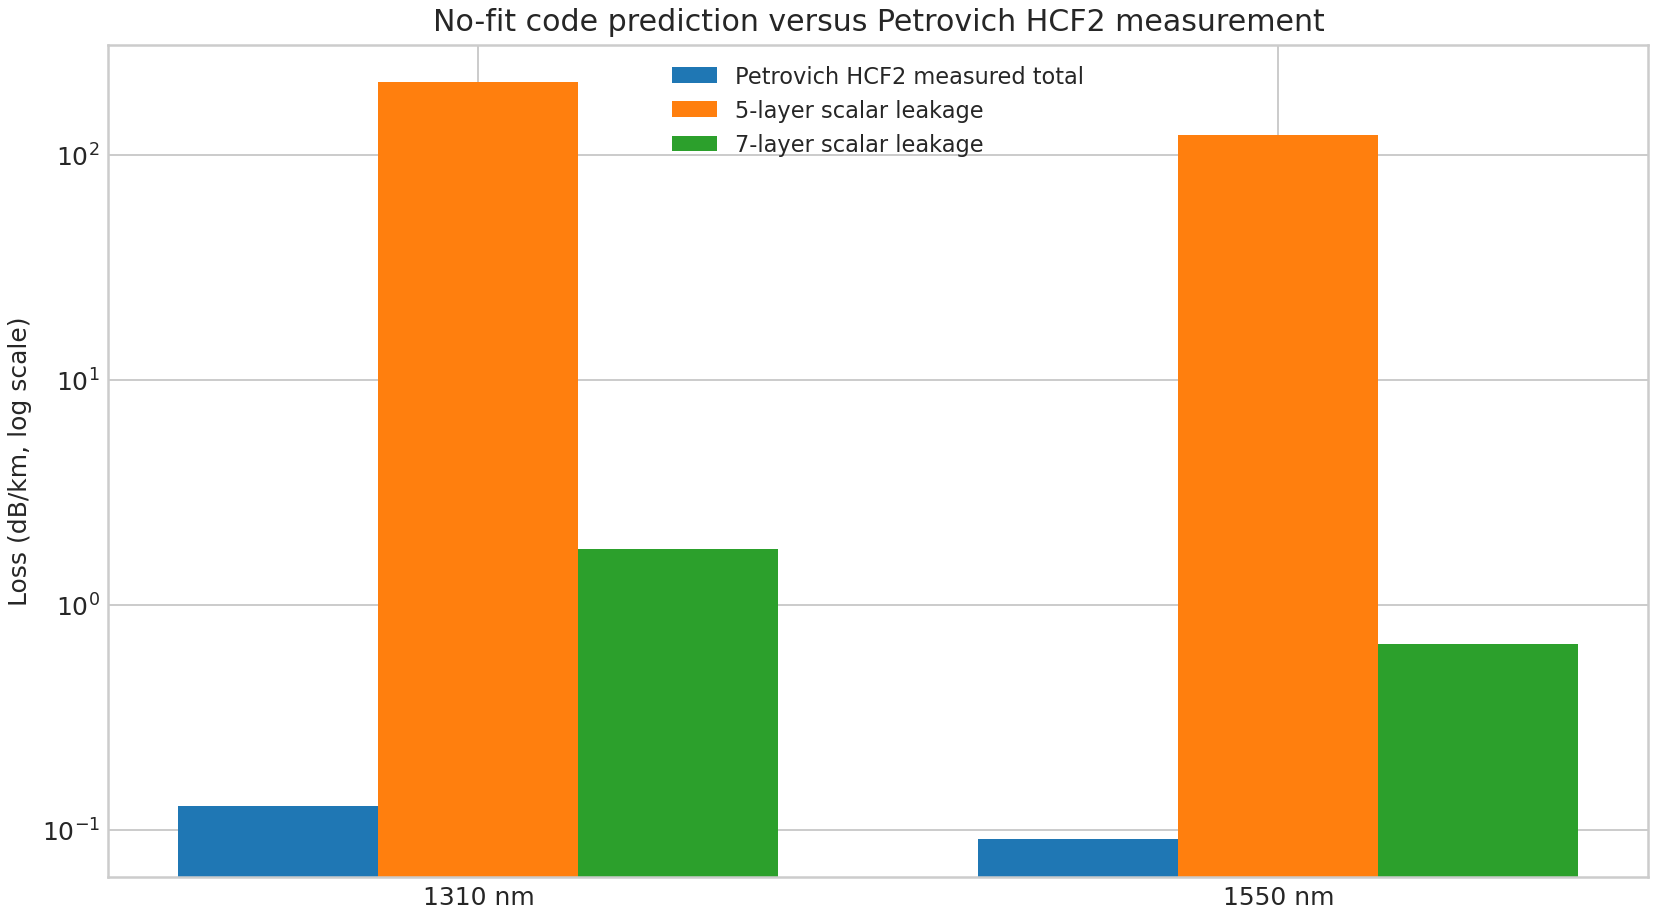

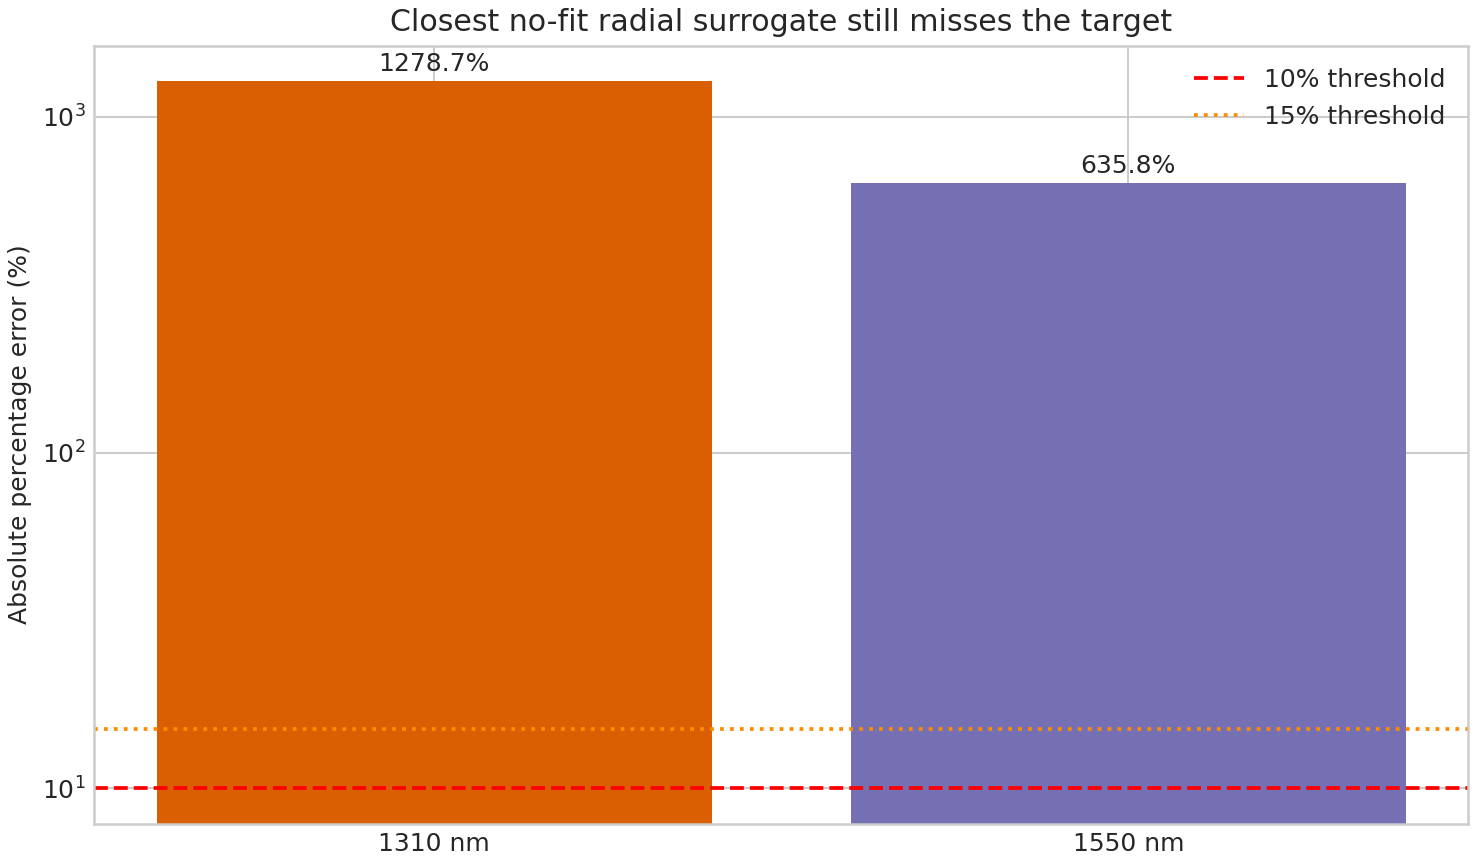

In [4]:
from IPython.display import Image, display
display(Image(filename="results/01_no_fit_loss_comparison.png"))
display(Image(filename="results/02_absolute_error_percent.png"))

## 3. 수치 solver 검산과 Bache/Bird 반영

3층 TMM은 같은 scalar TE 경계조건의 Bache bouncing-ray 닫힌식과 비교합니다. 추가된 planar multilayer 코드는 Bache Eq. (6), (15)–(17)의 반사율·bounce-rate 논리를 1·2·3개 유리막으로 확장합니다. `f_FEM`은 사용하지 않습니다.

wavelength_nm,three_layer_tmm_db_km,bache_te_closed_form_db_km,signed_error_percent,absolute_error_percent
1310.0,57017.731666,59681.024351,-4.462545,4.462545
1550.0,47037.045349,47781.677144,-1.558404,1.558404


wavelength_nm,stack,polarization,loss_db_km,f_FEM,target_used_for_fitting
1310.0,triple wall radial stack,TE,2.109966,NaN,False
1310.0,triple wall radial stack,TM,210.845919,NaN,False
1310.0,triple wall radial stack,hybrid,106.477942,NaN,False
1310.0,Bache Eq. 15-17 single wall,hybrid,156381.450859,NaN,False
1550.0,triple wall radial stack,TE,0.710464,NaN,False
1550.0,triple wall radial stack,TM,62.568699,NaN,False
1550.0,triple wall radial stack,hybrid,31.639581,NaN,False
1550.0,Bache Eq. 15-17 single wall,hybrid,126020.874408,NaN,False


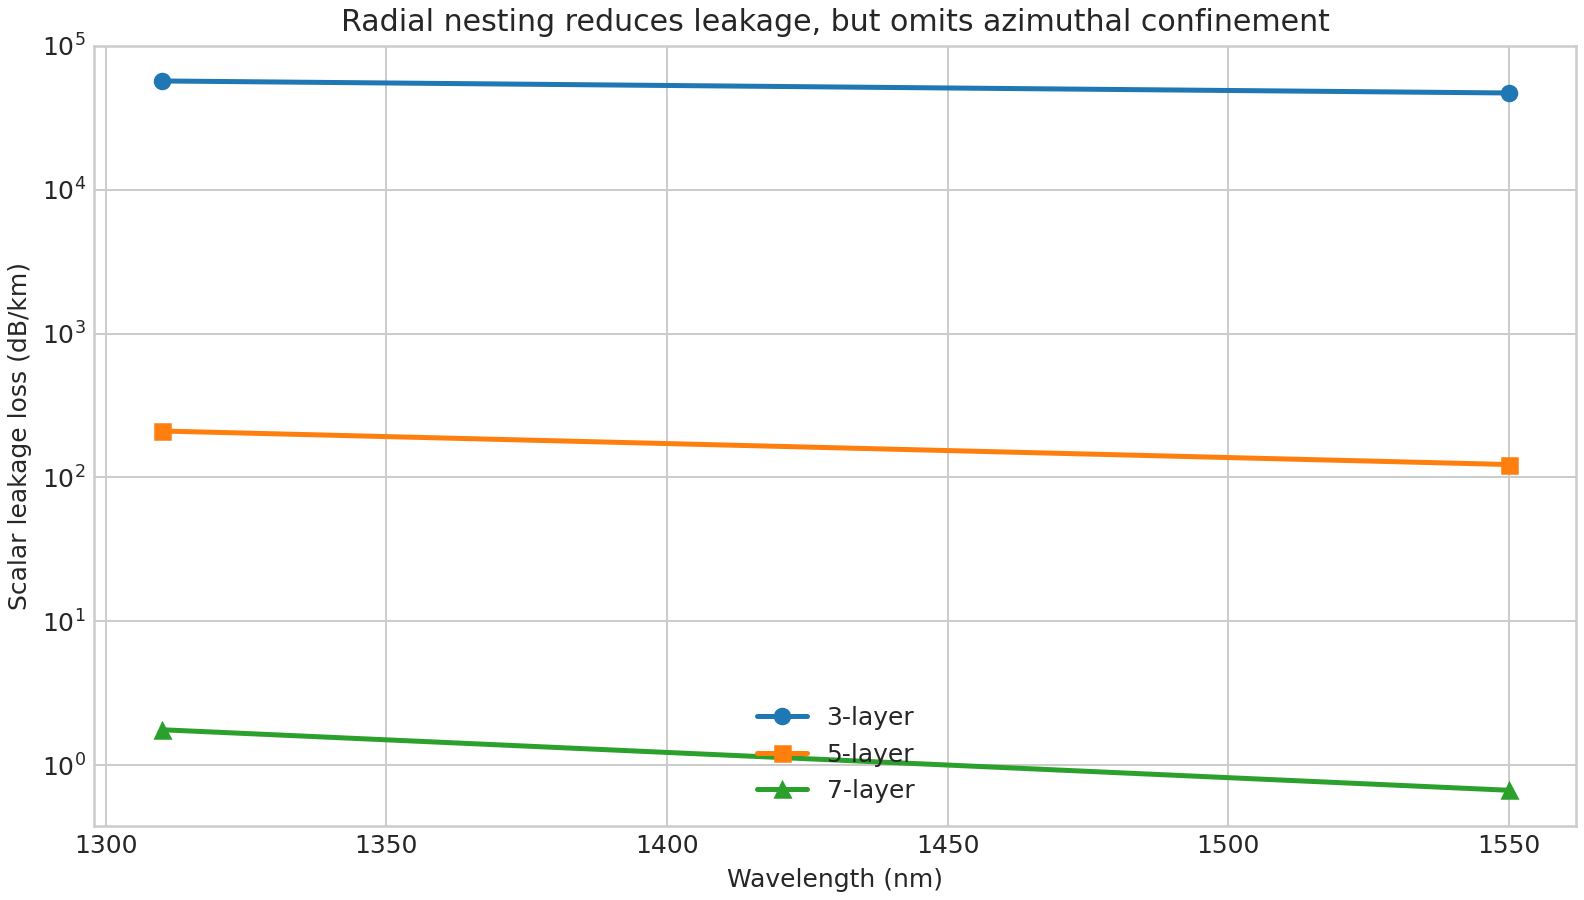

In [5]:
math_validation = pd.read_csv("results/02_three_layer_math_validation.csv")
bache = pd.read_csv("results/03_bache_multilayer_no_fit.csv")
display(math_validation)
display(bache[bache["stack"].str.contains("triple|Eq. 15", regex=True)])
display(Image(filename="results/03_radial_nesting_reduction.png"))

## 4. 공개 지름 범위 민감도

큰·중간·작은 튜브 지름의 최소/중간/최대 27개 조합을 전부 계산합니다. 논문 손실에 가장 가까운 조합을 선택하지 않으며, 비수렴점은 삭제하거나 숫자로 대체하지 않고 별도로 표시합니다.

wavelength_nm,min,median,max,paper_measured_total_db_km
1310.0,0.809994,1.764759,7.759229,0.128
1550.0,0.307240,0.636640,2.911431,0.091


Sweep points: 54 non-converged: 1


wavelength_nm,large_diameter_um,middle_diameter_um,small_diameter_um,gap1_um,gap2_um,root_message
1550.0,30.4,24.8,8.4,4.6,15.4,No independently verified fundamental-like root. No optimizer result stayed on 1.5<Re(u)<3.5 and -1<Im(u)<0.


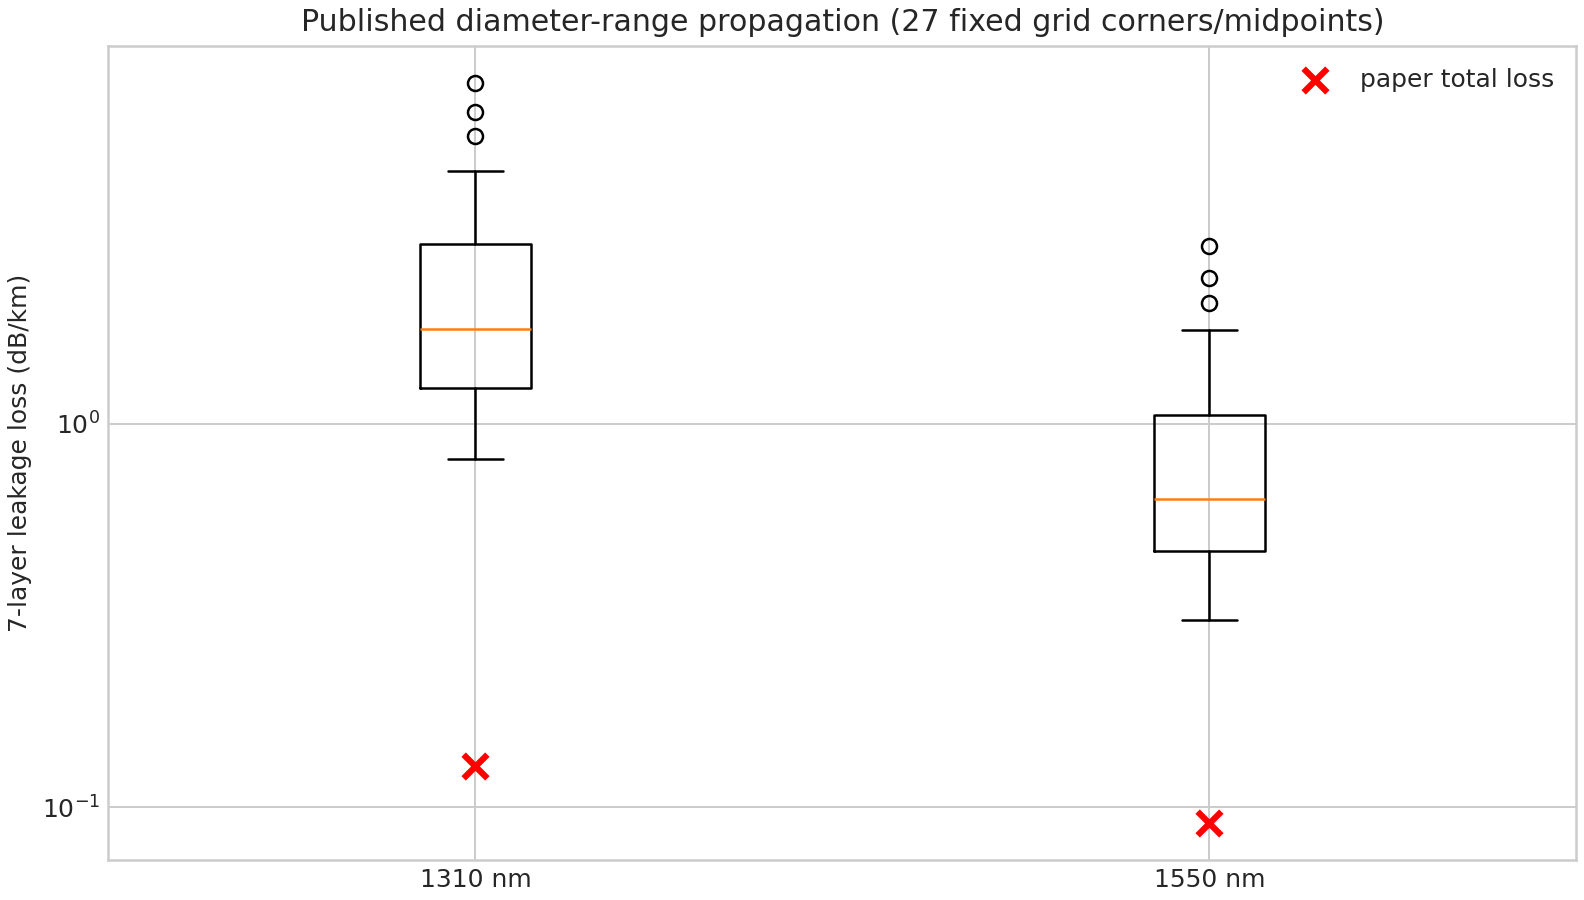

In [6]:
sweep = pd.read_csv("results/05_geometry_range_sweep.csv")
sweep_summary = pd.read_csv("results/06_geometry_range_summary.csv")
display(sweep_summary)
print("Sweep points:", len(sweep), "non-converged:", int((~sweep.converged).sum()))
if (~sweep.converged).any():
    display(sweep.loc[~sweep.converged, [
        "wavelength_nm", "large_diameter_um", "middle_diameter_um",
        "small_diameter_um", "gap1_um", "gap2_um", "root_message"
    ]])
display(Image(filename="results/04_geometry_range_sensitivity.png"))

## 5. 자동 판정 및 10% 초과 시 개선사항

In [7]:
summary = json.loads(Path("results/summary.json").read_text())
print("10% target passed:", summary["ten_percent_target_passed"])
print("15% target passed:", summary["fifteen_percent_target_passed"])
print("7-layer no-fit MAPE (%):", f'{summary["seven_layer_petrovich_mape_percent"]:.3f}')

if not summary["ten_percent_target_passed"]:
    improvements = [
        "1) 실제 5-tube double-nested SEM contour의 full-vector 2D complex-eigenvalue FEM + mesh/PML convergence",
        "2) Murphy–Bird(2023)의 azimuthal confinement과 radial glass web 반영",
        "3) leakage-only가 아니라 LL + SSL + microbend + gas absorption 총손실 구성",
        "4) 실제 막 두께·gap·타원도·튜브 각도·길이방향 변동·표면 roughness PSD·코팅/외경 입력 확보",
        "5) 보정계수가 필요하면 학습 fibre와 hold-out fibre를 분리하고 calibrated model로 명시",
    ]
    print("
오차율이 10%를 초과하므로 필요한 개선:")
    print("
".join(improvements))

print("
최종 판정: 현재 수정 코드는 radial nesting 경향과 수치해 검산에는 유효하지만, Petrovich HCF2 FEM/실측 절대손실을 대체하지 못합니다.")

10% target passed: False
15% target passed: False
7-layer no-fit MAPE (%): 957.258

오차율이 10%를 초과하므로 필요한 개선:
1) 실제 5-tube double-nested SEM contour의 full-vector 2D complex-eigenvalue FEM + mesh/PML convergence
2) Murphy–Bird(2023)의 azimuthal confinement과 radial glass web 반영
3) leakage-only가 아니라 LL + SSL + microbend + gas absorption 총손실 구성
4) 실제 막 두께·gap·타원도·튜브 각도·길이방향 변동·표면 roughness PSD·코팅/외경 입력 확보
5) 보정계수가 필요하면 학습 fibre와 hold-out fibre를 분리하고 calibrated model로 명시

최종 판정: 현재 수정 코드는 radial nesting 경향과 수치해 검산에는 유효하지만, Petrovich HCF2 FEM/실측 절대손실을 대체하지 못합니다.
